# An Example of ViT

based on dataset CIFAR10

## 基于论文AN IMAGE IS WORTH 16X16 WORDS:  TRANSFORMERS FOR IMAGE RECOGNITION AT SCALE
* 论文中使用16x16的patch，而CIFAR10是32x32的图片，我不需要做缩放。
* 我计划在本文中使用4x4的patch

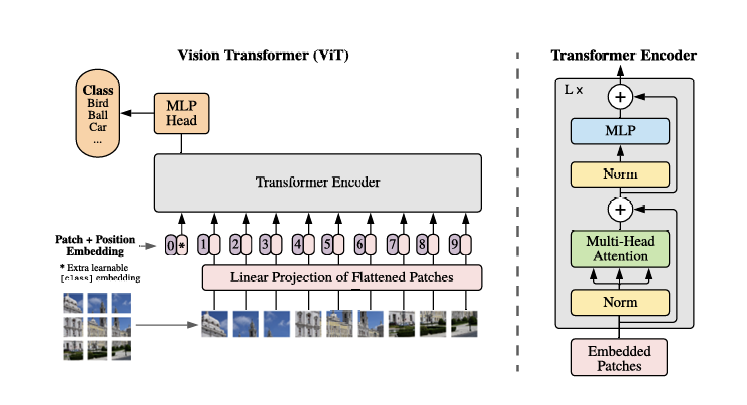

In [26]:
# modules
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy
# import PIL

* 由于patch为4x4，所以N=16
* 首先编写加载数据集的部分

In [27]:
# load data
# 训练集：加入数据增强（RandomCrop + RandomHorizontalFlip），提高泛化能力
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomCrop(32, padding=4),  # 随机裁剪
    torchvision.transforms.RandomHorizontalFlip(),      # 随机水平翻转
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # Normalize to [-1, 1]，归一化
])

# 测试集：仅标准化，不加增强
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # Normalize to [-1, 1]，归一化
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=train_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=test_transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("Data loaded successfully.")

# trainset.data.shape （50000, 32, 32, 3）
# 数据集的维度：数量 x 高度 x 宽度 x 通道数，三通道为RGB图像
# testset.data.shape （10000, 32, 32, 3）

Data loaded successfully.


## Transformer Encoder model

将图片分割为Patch并且导入Transformer Encoder学习，解码器中带有多头注意力机制和用于特征提取的MLP

我的MLP class复用了一次，更换激活函数为GELU，GELU近似计算为

$$ 
GELU(x) \approx 0.5x(1+tanh(\sqrt{\frac{2}{\pi}}(x+0.044715x^3)))
$$

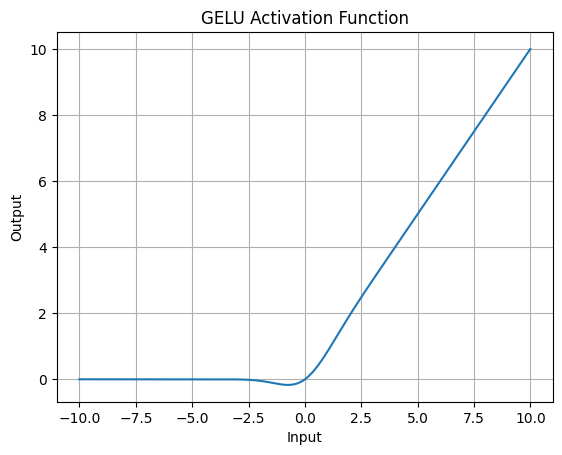

In [28]:
# plot GELU

import matplotlib.pyplot as plt
import numpy as np

def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

x = np.linspace(-10, 10, 1000)
y = gelu(x)

plt.plot(x, y)
plt.title('GELU Activation Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid()
plt.show()

In [29]:
# MLP
# 我会在Encoder中复用一次MLP，作为第二层Transformer Encoder的输出层，直接输出类别分数
# 这个模块会再次调用用于将Transformer Encoder的输出映射到类别数的全连接层，增加模型的表达能力

class MLP(nn.Module):
    def __init__(self, embed_dim=128, mlp_dim=256, output_dim=10, activation=F.relu, dropout = 0.1):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(embed_dim, mlp_dim)  # 将Transformer Encoder的输出映射到更高维度的隐藏层
        self.fc2 = nn.Linear(mlp_dim, output_dim)  # 将隐藏层映射到类别数
        self.activation = activation
        self.dropout = nn.Dropout(dropout)


    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
# Transformer Encoder
# Encoder中的MLP是复用过的，维度从D变成4D，再变回D，并且，我改变了它的激活函数为GELU。

class Encoder(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128, multi_attn = None,
                  MLP = MLP(mlp_dim=512, output_dim=128, activation=F.gelu), dropout = 0.1):
        super(Encoder, self).__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_embed = nn.Linear(in_channels * patch_size * patch_size, embed_dim)  # 将每个patch展平并映射到embed_dim维度
        
        self.multi_attn = multi_attn
        self.multi_attn2 = copy.deepcopy(multi_attn)
        self.multi_attn3 = copy.deepcopy(multi_attn)

        self.MLP = MLP
        self.MLP2 = copy.deepcopy(MLP)
        self.MLP3 = copy.deepcopy(MLP)
        
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)
        self.norm4 = nn.LayerNorm(embed_dim)
        self.norm5 = nn.LayerNorm(embed_dim)
        self.norm6 = nn.LayerNorm(embed_dim)
        self.norm_out = nn.LayerNorm(embed_dim)

        self.dropout = nn.Dropout(dropout)
    
    def add_positional_encoding(self, x):
        # 位置编码，使用正弦和余弦函数生成固定的编码
        B, N, D = x.shape
        pos_emb = torch.zeros(N, D).to(x.device)
        position = torch.arange(0, N).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, D, 2).float() * (-torch.log(torch.tensor(10000.0)) / D))
        pos_emb[:, 0::2] = torch.sin(position * div_term)
        pos_emb[:, 1::2] = torch.cos(position * div_term)
        return x + pos_emb.unsqueeze(0)  # 将位置编码添加到输入特征上

    def forward(self, x):
        B, C, H, W = x.shape
        # 将图像分割成patches并加入位置编码
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)  # (B, C, num_patches_h, num_patches_w, patch_size, patch_size)
        x = x.contiguous().view(B, C, -1, self.patch_size * self.patch_size)  # (B, C, num_patches, patch_size*patch_size)  contiguous()确保内存连续，view()改变张量形状，-1表示自动计算维度
        x = x.permute(0, 2, 1, 3).contiguous().view(B, self.num_patches, -1)  # (B, num_patches, C*patch_size*patch_size)
        x = self.patch_embed(x)  # (B, num_patches, embed_dim)
        x = self.add_positional_encoding(x)

        # Transformer Encoder
        # 第一层Transformer Encoder，利用Multi-Head Attention进行特征提取，并通过残差连接和LayerNorm进行稳定训练
        x_scaled = self.norm1(x)  # (B, num_patches, embed_dim)
        x = self.multi_attn(x_scaled) + x  # (B, num_patches, embed_dim)，残差连接
        x = self.dropout(x)
        # 第二层Transformer Encoder，提取特征、残差连接、归一化
        x_scaled = self.norm2(x)  # (B, num_patches, embed_dim)
        x = self.MLP(x_scaled) + x
        # x = self.dropout(x)

        x_scaled = self.norm3(x)  # (B, num_patches, embed_dim)
        x = self.multi_attn2(x_scaled) + x  # (B, num_patches, embed_dim)，残差连接
        x = self.dropout(x)  # 添加dropout，防止过拟合
        x_scaled = self.norm4(x)  # (B, num_patches, embed_dim)
        x = self.MLP2(x_scaled) + x

        x_scaled = self.norm5(x)  # (B, num_patches, embed_dim)
        x = self.multi_attn3(x_scaled) + x  # (B, num_patches, embed_dim)，残差连接
        x = self.dropout(x) 
        x_scaled = self.norm6(x)  # (B, num_patches, embed_dim)
        x = self.MLP3(x_scaled) + x


        # 池化、归一化、输出
        x = x.mean(dim=1)  # 平均池化，得到图像级别的特征表示 (B, embed_dim)
        x = self.norm_out(x)    # 输出前进行归一化，以供输入到MLP Classifier
        return x

In [31]:
# Multi-Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim=128, num_heads=8):
        super(MultiHeadAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)  # 同时生成查询、键、值的线性变换
        self.proj = nn.Linear(embed_dim, embed_dim)
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

    def forward(self, x):
        B, N, D = x.shape   # x.shape (B, num_patches, embed_dim)
        assert D == self.embed_dim, f"expected D={self.embed_dim}, got D={D}"
        qkv = self.qkv(x)
        qkv = qkv.view(B, N, self.num_heads, 3 * self.head_dim).permute(2, 0, 1, 3)  # (num_heads, B, N, 3*head_dim)
        q, k, v = qkv.chunk(3, dim=-1)  # (num_heads, B, N, head_dim)，拆分Q,K,V
        attn_scores = q @ k.transpose(-2, -1) / (self.head_dim ** 0.5)
        attn_scores = F.softmax(attn_scores, dim=-1)  # (num_heads, B, N, N)，计算注意力权重
        attn_output = attn_scores @ v  # (num_heads, B, N, head_dim)，加权求和得到注意力输出
        attn_output = attn_output.permute(1, 2, 0, 3).contiguous().view(B, N, D)  # (B, N, embed_dim)，重新组合多头输出
        output = self.proj(attn_output)  # (B, N, embed_dim)，线性变换得到最终输出
        return output

In [32]:
# ViT Model
class ViT(nn.Module):
    def __init__(self, encoder, classifier):
        super(ViT, self).__init__()
        self.encoder = encoder
        self.classifier = classifier

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x

## Train

训练采用Adam Optimizer，利用余弦退火算法进行学习率调整

余弦退火学习率公式如下：

$$
\eta_{t} = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})(1 + cos(\frac{\pi T_{cur}}{T_{max}}))
$$

In [33]:
# Trainer

import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

total_epoch = 70
lr_max = 0.0015
warmup_epochs = 5  # warmup 5个 epoch

def cosine_annealing_with_warmup(step, total_steps, warmup_steps, lr_max=lr_max, lr_min=1e-6):
    """Cosine annealing learning rate scheduler with linear warmup."""
    if step < warmup_steps:
        # Linear warmup
        return lr_max * (step / warmup_steps)
    else:
        # Cosine annealing
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * progress))

multi_attn = MultiHeadAttention(embed_dim=128, num_heads=8).to(device)
encoder = Encoder(multi_attn=multi_attn, dropout=0.15).to(device)  
classifier = MLP(output_dim=10, dropout=0.15).to(device)           

model = ViT(encoder=encoder, classifier=classifier).to(device)

loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr_max)

print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print(next(model.parameters()).device)

warmup_steps = warmup_epochs * len(trainloader)
total_steps = total_epoch * len(trainloader)

# score

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            output = model(images)
            predicted = output.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


model.train()
for epoch in range(total_epoch):
    total_loss = 0.0
    for batch_idx, (images, labels) in enumerate(trainloader):
        optimizer.zero_grad()
        output = model(images.to(device))
        loss = loss_fn(output, labels.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # 更新学习率（包括 warmup 和 cosine annealing）
        global_step = epoch * len(trainloader) + batch_idx
        current_lr = cosine_annealing_with_warmup(global_step, total_steps, warmup_steps, lr_max=lr_max, lr_min=1e-6)
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr

    print(f"Epoch {epoch+1}/{total_epoch}, Loss: {total_loss/len(trainloader):.4f}")

    if epoch % 10 == 9:  # 每10个epoch评估一次
        train_set_score = evaluate(trainloader)
        test_set_score = evaluate(testloader)
        print(f"Epoch {epoch+1} - Train Set Accuracy: {train_set_score:.4f}, Test Set Accuracy: {test_set_score:.4f}")

True NVIDIA GeForce RTX 5060 Laptop GPU
cuda:0
Epoch 1/70, Loss: 2.0124
Epoch 2/70, Loss: 1.6153
Epoch 3/70, Loss: 1.4395
Epoch 4/70, Loss: 1.3398
Epoch 5/70, Loss: 1.2901
Epoch 6/70, Loss: 1.2395
Epoch 7/70, Loss: 1.1715
Epoch 8/70, Loss: 1.1177
Epoch 9/70, Loss: 1.0684
Epoch 10/70, Loss: 1.0255
Epoch 10 - Train Set Accuracy: 0.6500, Test Set Accuracy: 0.6534
Epoch 11/70, Loss: 0.9570
Epoch 12/70, Loss: 0.9075
Epoch 13/70, Loss: 0.8636
Epoch 14/70, Loss: 0.8228
Epoch 15/70, Loss: 0.7896
Epoch 16/70, Loss: 0.7588
Epoch 17/70, Loss: 0.7263
Epoch 18/70, Loss: 0.6966
Epoch 19/70, Loss: 0.6737
Epoch 20/70, Loss: 0.6433
Epoch 20 - Train Set Accuracy: 0.7775, Test Set Accuracy: 0.7442
Epoch 21/70, Loss: 0.6239
Epoch 22/70, Loss: 0.6007
Epoch 23/70, Loss: 0.5830
Epoch 24/70, Loss: 0.5574
Epoch 25/70, Loss: 0.5385
Epoch 26/70, Loss: 0.5178
Epoch 27/70, Loss: 0.5012
Epoch 28/70, Loss: 0.4791
Epoch 29/70, Loss: 0.4652
Epoch 30/70, Loss: 0.4451
Epoch 30 - Train Set Accuracy: 0.8495, Test Set Accu

In [34]:
# score

# def evaluate(loader):
#     model.eval()
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for images, labels in loader:
#             images = images.to(device, non_blocking=True)
#             labels = labels.to(device, non_blocking=True)
#             output = model(images)
#             predicted = output.argmax(dim=1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
#     return correct / total

train_set_score = evaluate(trainloader)
test_set_score = evaluate(testloader)

print(f"Train Set Accuracy: {train_set_score:.4f}")
print(f"Test Set Accuracy: {test_set_score:.4f}")

Train Set Accuracy: 0.9772
Test Set Accuracy: 0.8063
